# **DUSt3R :3D Reconstruction From 2D Images :**

In [1]:
# uv pip install torch==2.7.0+cu118 torchvision==0.22.0+cu118 --index-url https://download.pytorch.org/whl/cu118

3D Reconstruction/
│
├── data/
│   └── input/
│       └── video.mp4
│
├── results/
│   └── dust3r/
│       │
│       ├── exp_01_baseline/
│       │   ├── dataset/
│       │   │   ├── frames/
│       │   │   └── dataset_info.json
│       │   │
│       │   ├── results/
│       │   │   ├── point_cloud.ply
│       │   │   ├── confidence.ply
│       │   │   └── metadata.json
│       │   │
│       │   └── logs/
│       │
│       ├── exp_02_oneref/
│       │   ├── dataset/
│       │   │   ├── frames/
│       │   │   └── dataset_info.json
│       │   │
│       │   ├── results/
│       │   │   ├── point_cloud.ply
│       │   │   └── metadata.json
│       │   │
│       │   └── logs/
│       │
│       ├── exp_03_more_frames/
│       │   ├── dataset/
│       │   ├── results/
│       │   └── logs/
│       │
│       └── ...
│
├── src/
│   └── dust3r/
│       ├── frame_extractor.py
│       ├── reconstruction.py
│       ├── visualization.py
│       └── pipeline.py
│
└── notebook/
    └── dust3r/
        ├── 01_data_processing.ipynb
        ├── 02_two_image_test.ipynb
        ├── 03_global_alignment.ipynb
        └── 04_experiments.ipynb

## **Dust3R dataset Preprocessing :**

In [1]:
experiment='03'

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "3D Reconstruction":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Our project code
sys.path.insert(0, str(PROJECT_ROOT))

# Official DUSt3R repository
sys.path.insert(0, str(PROJECT_ROOT / "dust3r"))

print("Project root:", PROJECT_ROOT)
print("Official DUSt3R:", PROJECT_ROOT / "dust3r")

Project root: d:\3D Reconstruction
Official DUSt3R: d:\3D Reconstruction\dust3r


In [4]:
from src.dust3r.data_preprocessing import extract_uniform_frames

In [5]:
Path.cwd().parent

WindowsPath('d:/3D Reconstruction/notebook')

In [6]:


video_path = PROJECT_ROOT / "video"/ "video.mp4"

video_path

WindowsPath('d:/3D Reconstruction/video/video.mp4')

In [7]:


output_dir = (
        PROJECT_ROOT
        /"src"
        / "results"
        / "dust3r"
        / f"exp_{experiment}_baseline"
        / "dataset"
        / "frames"
    )

extract_uniform_frames(
        video_path=video_path,
        output_dir=output_dir,
        num_frames=150,
    )

Video: d:\3D Reconstruction\video\video.mp4
Original frames: 397
Original FPS: 30.00
Selected frames: 150
Saved to: d:\3D Reconstruction\src\results\dust3r\exp_03_baseline\dataset\frames
Metadata: d:\3D Reconstruction\src\results\dust3r\exp_03_baseline\dataset\dataset_info.json


In [8]:

frames=sorted(output_dir.glob("*.jpg"))

print(f'Number of Frames : {len(frames)}')

for frame in frames:
    print(frame.name)

Number of Frames : 150
frame_0000.jpg
frame_0001.jpg
frame_0002.jpg
frame_0003.jpg
frame_0004.jpg
frame_0005.jpg
frame_0006.jpg
frame_0007.jpg
frame_0008.jpg
frame_0009.jpg
frame_0010.jpg
frame_0011.jpg
frame_0012.jpg
frame_0013.jpg
frame_0014.jpg
frame_0015.jpg
frame_0016.jpg
frame_0017.jpg
frame_0018.jpg
frame_0019.jpg
frame_0020.jpg
frame_0021.jpg
frame_0022.jpg
frame_0023.jpg
frame_0024.jpg
frame_0025.jpg
frame_0026.jpg
frame_0027.jpg
frame_0028.jpg
frame_0029.jpg
frame_0030.jpg
frame_0031.jpg
frame_0032.jpg
frame_0033.jpg
frame_0034.jpg
frame_0035.jpg
frame_0036.jpg
frame_0037.jpg
frame_0038.jpg
frame_0039.jpg
frame_0040.jpg
frame_0041.jpg
frame_0042.jpg
frame_0043.jpg
frame_0044.jpg
frame_0045.jpg
frame_0046.jpg
frame_0047.jpg
frame_0048.jpg
frame_0049.jpg
frame_0050.jpg
frame_0051.jpg
frame_0052.jpg
frame_0053.jpg
frame_0054.jpg
frame_0055.jpg
frame_0056.jpg
frame_0057.jpg
frame_0058.jpg
frame_0059.jpg
frame_0060.jpg
frame_0061.jpg
frame_0062.jpg
frame_0063.jpg
frame_0064.jpg
fr

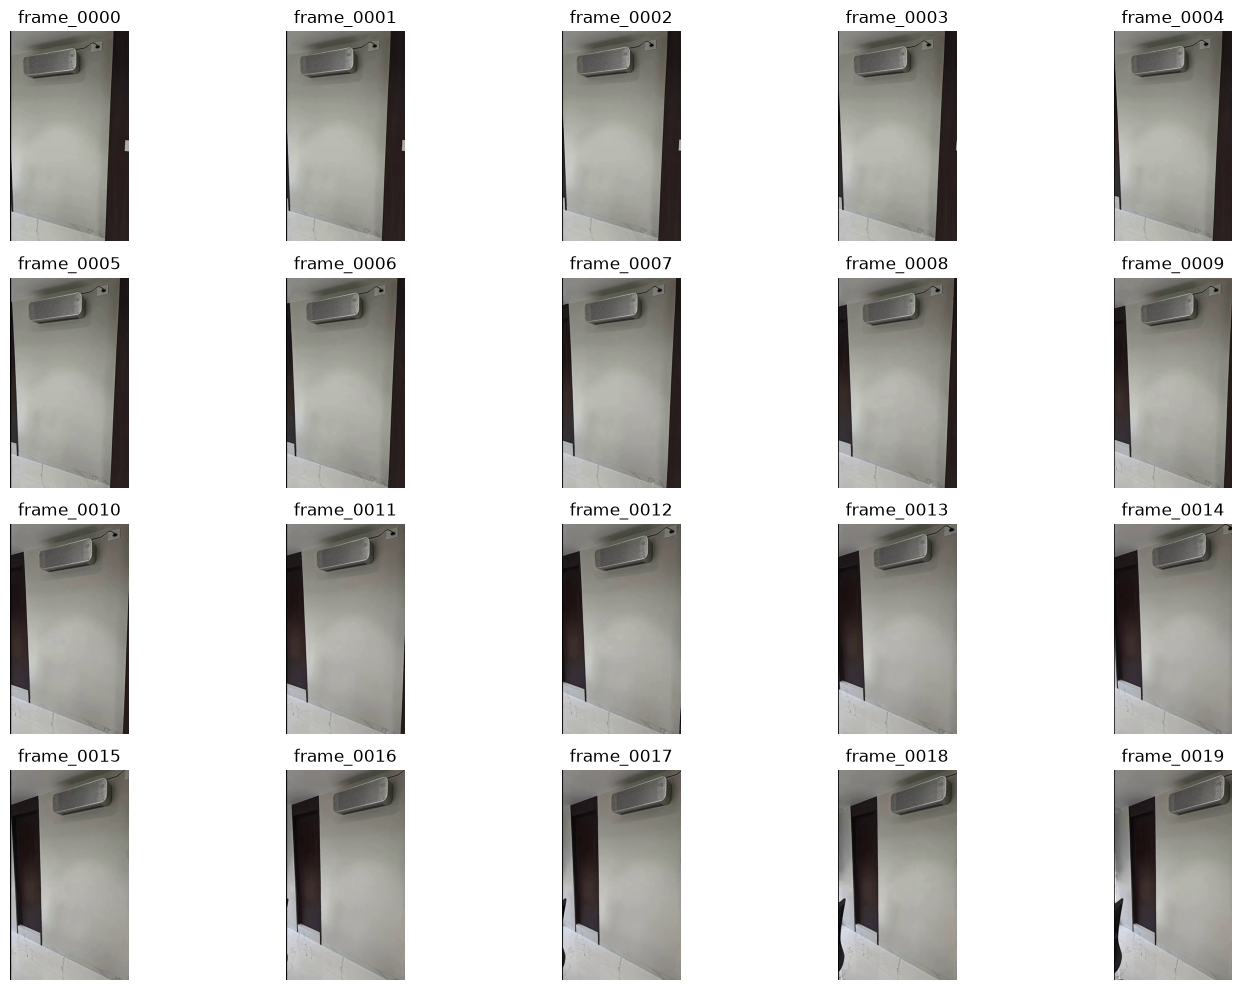

In [9]:
import matplotlib.pyplot as plt
from PIL import Image


fig,axes=plt.subplots(4,5,figsize=(15,10))

for ax ,frame_path in zip(axes.flat,frames):
    image=Image.open(frame_path)

    ax.imshow(image)
    ax.set_title(frame_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
from PIL import Image

for frame_path in frames[:3]:
    image = Image.open(frame_path)

    print(
        frame_path.name,
        "size =", image.size,
        "mode =", image.mode
    )

frame_0000.jpg size = (408, 720) mode = RGB
frame_0001.jpg size = (408, 720) mode = RGB
frame_0002.jpg size = (408, 720) mode = RGB


## **Working with Dust3R Model :**

In [11]:
# !git clone --recursive https://github.com/naver/dust3r

In [12]:
# # * downloading the Model :

from src.dust3r.model_manager import get_checkpoint

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "dust3r"
    / "checkpoints"
)

CHECKPOINT_DIR


WindowsPath('d:/3D Reconstruction/dust3r/checkpoints')

In [13]:
checkpoint_path = get_checkpoint(
    model_name="512_dpt",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)

Checkpoint already exists:
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth


In [14]:
checkpoint_path = get_checkpoint(
    model_name="512_linear",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)

Checkpoint already exists:
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth


In [15]:
checkpoint_path = get_checkpoint(
    model_name="224_linear",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)

Checkpoint already exists:
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth
d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth


## **Loading the Model + Inference Test :**

In [16]:
import dust3r

print(dust3r.__file__)

d:\3D Reconstruction\dust3r\dust3r\__init__.py


In [3]:
from pathlib import Path

from src.dust3r.reconstruction import reconstruct



frames_dir = (
    PROJECT_ROOT
    /"src"
    / "results"
    / "dust3r"
    / f"exp_{experiment}_baseline"
    / "dataset"
    / "frames"
)

checkpoint_path = (
    PROJECT_ROOT
    / "dust3r"
    / "checkpoints"
    / "DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth"
)

output_dir = (
    PROJECT_ROOT
    /"src"
    / "results"
    / "dust3r"
    / f"exp_{experiment}_baseline"
    / "results"
)



d:\3D Reconstruction\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [18]:
print(frames_dir)
print(frames_dir.exists())
print(list(frames_dir.glob("*"))[:10])

d:\3D Reconstruction\src\results\dust3r\exp_03_baseline\dataset\frames
True
[WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0000.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0001.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0002.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0003.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0004.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0005.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0006.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0007.jpg'), WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_03_baseline/dataset/frames/frame_0008.jpg'), Windo

In [19]:
reconstruct(
    frames_dir=frames_dir,
    checkpoint_path=checkpoint_path,
    output_dir=output_dir,
)

Device: cuda
Frames: d:\3D Reconstruction\src\results\dust3r\exp_03_baseline\dataset\frames
Checkpoint: d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead

Loading DUSt3R model...
... loading model from d:\3D Reconstruction\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
instantiating : AsymmetricCroCo3DStereo(enc_depth=24, dec_depth=12, enc_embed_dim=1024, dec_embed_dim=768, enc_num_heads=16, dec_num_heads=12, pos_embed='RoPE100', patch_embed_cls='PatchEmbedDust3R', img_size=(512, 512), head_type='dpt', output_mode='pts3d', depth_mode=('exp', -inf, inf), conf_mode=('exp', 1, inf), landscape_only=False)
<All keys matched successfully>
Model loaded.

Loading 150 images...
>> Loading a list of 150 images
 - adding d:\3D Reconstruction\src\results\dust3r\exp_03_baseline\dataset\frames\frame_0000.jpg with resolution 408x720 --> 288x512
 - adding d:\3D Reconstru

  0%|          | 0/600 [00:00<?, ?it/s]d:\3D Reconstruction\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
d:\3D Reconstruction\dust3r\dust3r\model.py:264: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
d:\3D Reconstruction\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 600/600 [02:43<00:00,  3.68it/s]


Inference completed.

Running global alignment...
 init edge (128*,126*) score=np.float64(206.94619750976562)
 init edge (128,130*) score=np.float64(197.28163146972656)
 init edge (124*,126) score=np.float64(179.7398223876953)
 init edge (129*,130) score=np.float64(174.93331909179688)
 init edge (122*,124) score=np.float64(168.7205047607422)
 init edge (130,132*) score=np.float64(163.63755798339844)
 init edge (127*,129) score=np.float64(162.56788635253906)
 init edge (123*,124) score=np.float64(160.5963592529297)
 init edge (130,131*) score=np.float64(156.30389404296875)
 init edge (121*,123) score=np.float64(119.87708282470703)
 init edge (132,134*) score=np.float64(115.3227310180664)
 init edge (122,120*) score=np.float64(105.10853576660156)
 init edge (118*,120) score=np.float64(92.53857421875)
 init edge (133*,134) score=np.float64(90.78706359863281)
 init edge (134,136*) score=np.float64(89.58184814453125)
 init edge (119*,120) score=np.float64(78.06100463867188)
 init edge (116*

  0%|          | 0/300 [00:03<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 1014.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 14.35 GiB is allocated by PyTorch, and 2.02 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
output_dir

WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_02_baseline/results')

In [ ]:
point_cloud=output_dir/"point_cloud.ply"
point_cloud

WindowsPath('d:/3D Reconstruction/src/results/dust3r/exp_02_baseline/results/point_cloud.ply')

In [ ]:
import open3d as o3d

point_cloud=output_dir/"point_cloud.ply"


dense_pcd = o3d.io.read_point_cloud(
    point_cloud
)


print(dense_pcd)
print("Dense points:", len(dense_pcd.points))

PointCloud with 13778889 points.
Dense points: 13778889


In [ ]:
o3d.visualization.draw_geometries([dense_pcd])
